In [1]:
from skclust.hierarchical import HierarchicalClustering
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# Generate test data
X, y_true = make_blobs(n_samples=100, centers=4, n_features=5, random_state=42)
df = pd.DataFrame(X, index=[f"sample_{i}" for i in range(100)])

# --- 1. Hybrid (default, matches R's cutreeDynamic(method="hybrid")) ---
hc_hybrid = HierarchicalClustering(method='ward', cut_method='hybrid')
labels_hybrid = hc_hybrid.fit_transform(df)
print("=== hybrid (default R params: deep_split=1, min_cluster_size=20) ===")
print(f"  n_clusters: {hc_hybrid.n_clusters_}, n_outliers: {hc_hybrid.n_outliers_}")
print(f"  labels: {np.unique(labels_hybrid)}\n")

# --- 2. 'dynamic' alias (should behave identically to 'hybrid') ---
hc_dynamic = HierarchicalClustering(method='ward', cut_method='dynamic')
labels_dynamic = hc_dynamic.fit_transform(df)
print("=== dynamic (alias for hybrid) ===")
print(f"  n_clusters: {hc_dynamic.n_clusters_}, n_outliers: {hc_dynamic.n_outliers_}")
print(f"  identical to hybrid: {np.array_equal(labels_hybrid, labels_dynamic)}\n")

# --- 3. Hybrid with PAM stage disabled ---
hc_no_pam = HierarchicalClustering(method='ward', cut_method='hybrid', pam_stage=False)
labels_no_pam = hc_no_pam.fit_transform(df)
print("=== hybrid (pam_stage=False) ===")
print(f"  n_clusters: {hc_no_pam.n_clusters_}, n_outliers: {hc_no_pam.n_outliers_}")
print(f"  more outliers without PAM: {hc_no_pam.n_outliers_ >= hc_hybrid.n_outliers_}\n")

# --- 4. Hybrid with different deep_split levels ---
print("=== hybrid deep_split sweep ===")
for ds in range(5):
    hc = HierarchicalClustering(method='ward', cut_method='hybrid', deep_split=ds, min_cluster_size=5)
    hc.fit(df)
    print(f"  deep_split={ds}: n_clusters={hc.n_clusters_}, n_outliers={hc.n_outliers_}")
print()

# --- 5. 'tree' method (dendrogram-only, no distance matrix) ---
hc_tree = HierarchicalClustering(method='ward', cut_method='tree', deep_split=True, min_cluster_size=5)
labels_tree = hc_tree.fit_transform(df)
print("=== tree (deep_split=True) ===")
print(f"  n_clusters: {hc_tree.n_clusters_}, n_outliers: {hc_tree.n_outliers_}\n")

hc_tree_no_ds = HierarchicalClustering(method='ward', cut_method='tree', deep_split=False, min_cluster_size=5)
labels_tree_no_ds = hc_tree_no_ds.fit_transform(df)
print("=== tree (deep_split=False) ===")
print(f"  n_clusters: {hc_tree_no_ds.n_clusters_}, n_outliers: {hc_tree_no_ds.n_outliers_}\n")

# --- 6. Coercion logging: int deep_split with 'tree', bool with 'hybrid' ---
print("=== coercion tests (check log messages above) ===")
hc_coerce_tree = HierarchicalClustering(method='ward', cut_method='tree', deep_split=2, min_cluster_size=5)
hc_coerce_tree.fit(df)
print(f"  tree with deep_split=2 -> coerced to {hc_coerce_tree.deep_split}")

hc_coerce_hybrid = HierarchicalClustering(method='ward', cut_method='hybrid', deep_split=True)
hc_coerce_hybrid.fit(df)
print(f"  hybrid with deep_split=True -> coerced to {hc_coerce_hybrid.deep_split}\n")

# --- 7. Hybrid PAM parameters ---
hc_pam_opts = HierarchicalClustering(
    method='ward', cut_method='hybrid',
    pam_respects_dendro=False, use_medoids=True,
    max_pam_dist=10.0, respect_small_clusters=False,
)
hc_pam_opts.fit(df)
print("=== hybrid with custom PAM options ===")
print(f"  n_clusters: {hc_pam_opts.n_clusters_}, n_outliers: {hc_pam_opts.n_outliers_}\n")

# --- 8. Compare all cut methods side by side ---
print("=== all cut_methods comparison ===")
methods = {
    'hybrid': dict(cut_method='hybrid', min_cluster_size=5),
    'dynamic': dict(cut_method='dynamic', min_cluster_size=5),
    'tree': dict(cut_method='tree', deep_split=True, min_cluster_size=5),
    'height': dict(cut_method='height', cut_threshold=15.0),
    'maxclust': dict(cut_method='maxclust', cut_threshold=4),
}
for name, params in methods.items():
    hc = HierarchicalClustering(method='ward', **params)
    hc.fit(df)
    print(f"  {name:10s}: n_clusters={hc.n_clusters_}, n_outliers={hc.n_outliers_}")

2026-06-19 10:13:31.923 | INFO     | skclust.hierarchical:__init__:233 - deep_split converted from int to bool (True) for cut_method='tree'
2026-06-19 10:13:31.925 | INFO     | skclust.hierarchical:__init__:227 - deep_split converted from bool to int (1) for cut_method='hybrid'


..cutHeight not given, setting it to 122.62518768695175  ===>  99% of the (truncated) height range in dendro.
=== hybrid (default R params: deep_split=1, min_cluster_size=20) ===
  n_clusters: 4, n_outliers: 0
  labels: [0 1 2 3]

..cutHeight not given, setting it to 122.62518768695175  ===>  99% of the (truncated) height range in dendro.
=== dynamic (alias for hybrid) ===
  n_clusters: 4, n_outliers: 0
  identical to hybrid: True

..cutHeight not given, setting it to 122.62518768695175  ===>  99% of the (truncated) height range in dendro.
=== hybrid (pam_stage=False) ===
  n_clusters: 4, n_outliers: 0
  more outliers without PAM: True

=== hybrid deep_split sweep ===
..cutHeight not given, setting it to 122.62518768695175  ===>  99% of the (truncated) height range in dendro.
  deep_split=0: n_clusters=4, n_outliers=0
..cutHeight not given, setting it to 122.62518768695175  ===>  99% of the (truncated) height range in dendro.
  deep_split=1: n_clusters=4, n_outliers=0
..cutHeight not g

=== Testing HierarchicalClustering Key Functionalities ===

1. Testing cluster prefix...
   Cluster labels: ['C1' 'C2' 'C3' 'C4']
   Tree built: True

2. Testing dynamic tree cutting...
..cutHeight not given, setting it to 45.190625109118194  ===>  99% of the (truncated) height range in dendro.
..done.
   Dynamic clusters: [1 2 3 4]

3. Testing NetworkX support...
   NetworkX support available

4. Testing continuous tracks...
   Added continuous track: ['Gene_Expression']

5. Testing categorical tracks...
   All tracks: ['Gene_Expression', 'Treatment_Type']

6. Tree building successful: True

7. Testing visualization...
   Plot generated successfully

8. Clustering summary:
Hierarchical Clustering Summary
n_samples: 30
n_clusters: 4
method: ward
metric: euclidean
cut_method: maxclust

Cluster sizes:
  Cluster C1: 7 samples
  Cluster C2: 8 samples
  Cluster C3: 7 samples
  Cluster C4: 8 samples

✅ All key functionalities tested successfully!


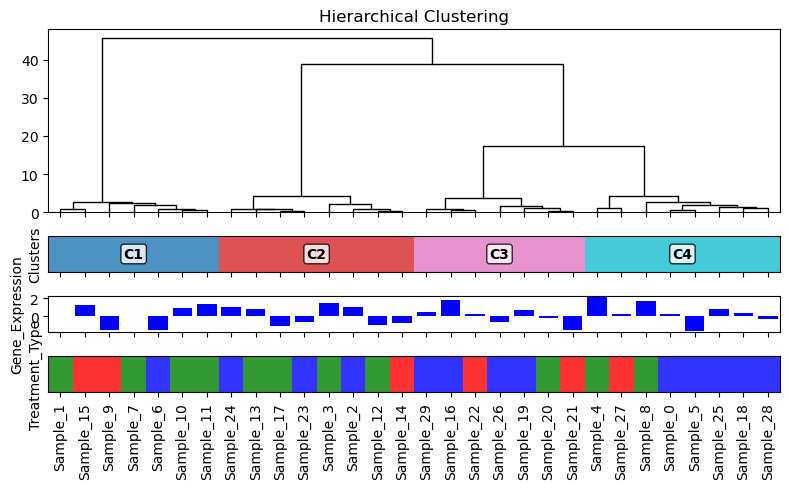

In [1]:
# Simple test for HierarchicalClustering - all key functionalities
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from skclust.hierarchical import HierarchicalClustering

# Create test data with clear clusters
X, y_true = make_blobs(n_samples=30, centers=4, cluster_std=1.0, random_state=42)
df = pd.DataFrame(X, index=[f"Sample_{i}" for i in range(30)], columns=['Feature1', 'Feature2'])

print("=== Testing HierarchicalClustering Key Functionalities ===\n")

# 1. Test basic clustering with cluster prefix
print("1. Testing cluster prefix...")
hc = HierarchicalClustering(method='ward', cut_method='maxclust', cut_threshold=4, cluster_prefix='C')
labels = hc.fit_transform(df)
print(f"   Cluster labels: {np.unique(labels)}")
print(f"   Tree built: {hc.tree_ is not None}")

# 2. Test dynamic tree cutting
print("\n2. Testing dynamic tree cutting...")
hc_dynamic = HierarchicalClustering(method='ward', cut_method='dynamic', min_cluster_size=3, deep_split=2)
try:
    labels_dynamic = hc_dynamic.fit_transform(df)
    print(f"   Dynamic clusters: {np.unique(labels_dynamic)}")
except Exception as e:
    print(f"   Dynamic cutting not available: {e}")

# 3. Test NetworkX support (if available)
print("\n3. Testing NetworkX support...")
try:
    from ensemble_networkx import Symmetric
    # This would test NetworkX Symmetric object input
    print("   NetworkX support available")
except ImportError:
    print("   NetworkX ensemble not available (optional)")

# 4. Test adding continuous track via pd.Series
print("\n4. Testing continuous tracks...")
continuous_track = pd.Series(np.random.normal(0, 1, 30), index=df.index, name='Expression')
hc.add_track('Gene_Expression', continuous_track, track_type='continuous', color='blue')
print(f"   Added continuous track: {list(hc.tracks_.keys())}")

# 5. Test adding categorical track via pd.Series  
print("\n5. Testing categorical tracks...")
categories = ['TypeA', 'TypeB', 'TypeC']
categorical_track = pd.Series(np.random.choice(categories, 30), index=df.index, name='Treatment')
color_map = {'TypeA': 'red', 'TypeB': 'green', 'TypeC': 'blue'}
hc.add_track('Treatment_Type', categorical_track, track_type='categorical', color=color_map)
print(f"   All tracks: {list(hc.tracks_.keys())}")

# 6. Test tree building (already tested above, but verify)
print(f"\n6. Tree building successful: {hc.tree_ is not None}")

# 7. Test plotting with all features
print("\n7. Testing visualization...")
fig, axes = hc.plot(figsize=(8,5), show_clusters=True, show_tracks=True, show_cluster_labels=True)
print("   Plot generated successfully")

# 8. Summary
print("\n8. Clustering summary:")
summary = hc.summary()

print("\n✅ All key functionalities tested successfully!")

..cutHeight not given, setting it to 82.86482631555863  ===>  99% of the (truncated) height range in dendro.
..done.
Found 4 clusters


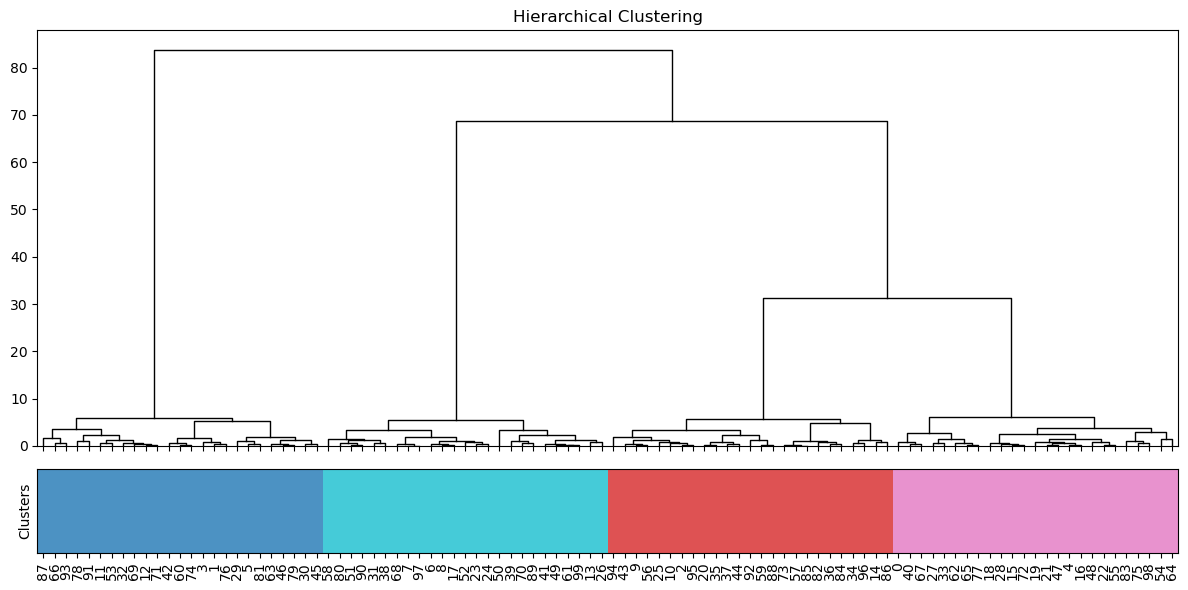

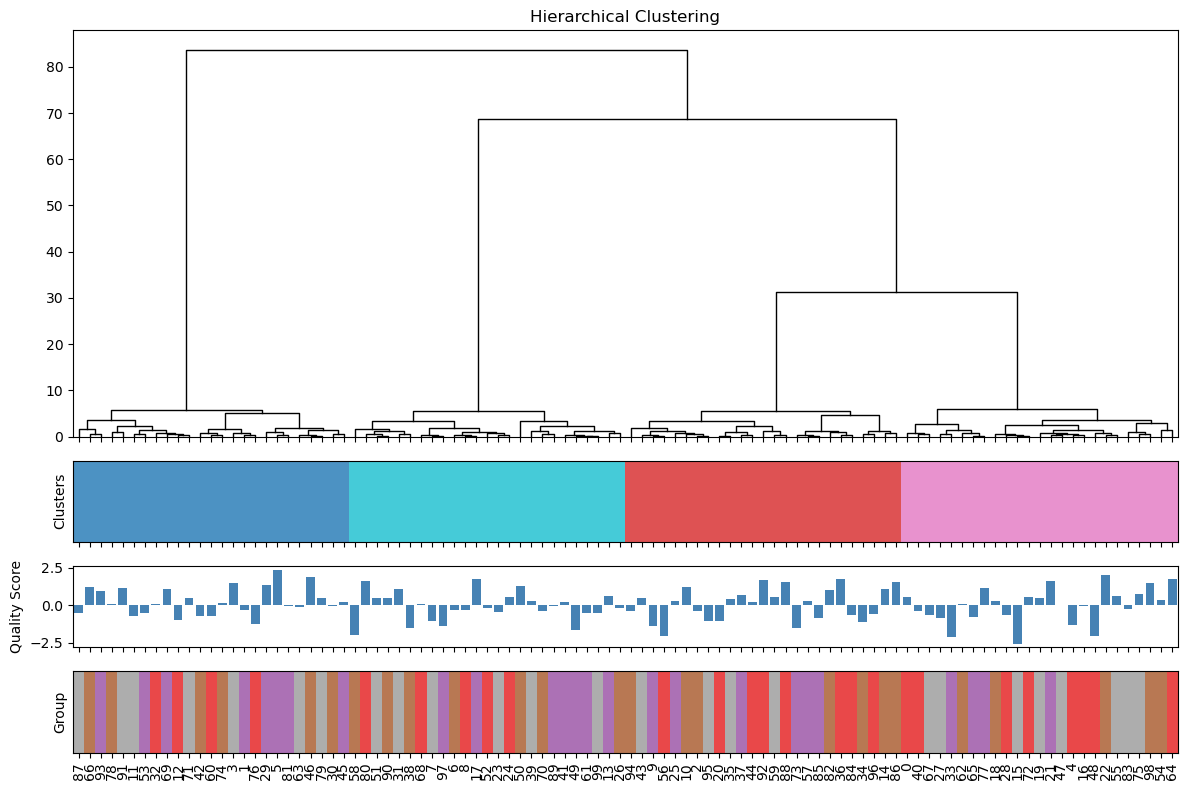

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
from skclust.hierarchical import HierarchicalClustering

# Generate sample data
X, y = make_blobs(n_samples=100, centers=4, random_state=42)
X_df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])

# Perform hierarchical clustering
hc = HierarchicalClustering(
    method='ward',
    cut_method='dynamic',
    min_cluster_size=5
)

# Fit and get cluster labels
labels = hc.fit_transform(X_df)
print(f"Found {hc.n_clusters_} clusters")

# Plot dendrogram with clusters
fig, axes = hc.plot(figsize=(12, 6), show_clusters=True)

# Add continuous metadata track
sample_scores = pd.Series(np.random.randn(100), index=X_df.index)
hc.add_track('Quality Score', sample_scores, track_type='continuous')

# Add categorical metadata track
sample_groups = pd.Series(['A', 'B', 'C', 'D'] * 25, index=X_df.index[:100])
hc.add_track('Group', sample_groups, track_type='categorical')

# Plot with metadata tracks
fig, axes = hc.plot(show_tracks=True, figsize=(12, 8))

In [3]:
# Cut by height
hc_height = HierarchicalClustering(
    method='ward',
    cut_method='height',
    cut_threshold=50.0,
)
labels_height = hc_height.fit_transform(X_df)

# Cut by number of clusters
hc_maxclust = HierarchicalClustering(
    method='complete',
    cut_method='maxclust',
    cluster_prefix="c",
    cut_threshold=5  # Force exactly 5 clusters
    
)
labels_maxclust = hc_maxclust.fit_transform(X_df)
labels_maxclust

array(['c5', 'c1', 'c4', 'c1', 'c5', 'c1', 'c3', 'c3', 'c3', 'c4', 'c4',
       'c1', 'c1', 'c3', 'c4', 'c5', 'c5', 'c3', 'c5', 'c5', 'c4', 'c5',
       'c5', 'c3', 'c3', 'c4', 'c3', 'c5', 'c5', 'c1', 'c1', 'c2', 'c1',
       'c5', 'c4', 'c4', 'c4', 'c4', 'c2', 'c2', 'c5', 'c3', 'c1', 'c4',
       'c4', 'c1', 'c1', 'c5', 'c5', 'c3', 'c3', 'c2', 'c3', 'c1', 'c5',
       'c5', 'c4', 'c4', 'c2', 'c4', 'c1', 'c3', 'c5', 'c1', 'c5', 'c5',
       'c1', 'c5', 'c3', 'c1', 'c2', 'c1', 'c5', 'c4', 'c1', 'c5', 'c1',
       'c5', 'c1', 'c1', 'c2', 'c1', 'c4', 'c5', 'c4', 'c4', 'c4', 'c1',
       'c4', 'c2', 'c2', 'c1', 'c4', 'c1', 'c4', 'c4', 'c4', 'c3', 'c5',
       'c3'], dtype=object)

In [4]:
from scipy.spatial.distance import pdist, squareform

# Compute custom distance matrix
distances = pdist(X_df, metric='cosine')
distance_matrix = pd.DataFrame(squareform(distances), 
                              index=X_df.index, 
                              columns=X_df.index)

# Cluster using precomputed distances
hc_custom = HierarchicalClustering(method='average')
labels_custom = hc_custom.fit_transform(distance_matrix)

..cutHeight not given, setting it to 1.4096950118136868  ===>  99% of the (truncated) height range in dendro.
..done.
